# **1. Perkenalan Dataset**


## Pengenalan Dataset

Pada eksperimen ini digunakan **Churn Modelling Dataset** yang berisi informasi mengenai pelanggan bank. Dataset ini digunakan untuk memprediksi apakah seorang pelanggan akan berhenti menggunakan layanan bank (*customer churn*) atau tidak.

### Sumber Dataset
Dataset diperoleh dari platform Kaggle pada tautan berikut:

https://www.kaggle.com/datasets/shubh0799/churn-modelling

### Deskripsi Dataset
Dataset ini berisi berbagai atribut pelanggan yang dapat digunakan untuk menganalisis perilaku pelanggan dan memprediksi kemungkinan churn. Setiap baris data merepresentasikan satu pelanggan bank dengan berbagai karakteristik demografis dan finansial.

Beberapa fitur utama dalam dataset antara lain:

- **CreditScore** : Nilai kredit pelanggan.
- **Geography** : Negara asal pelanggan.
- **Gender** : Jenis kelamin pelanggan.
- **Age** : Usia pelanggan.
- **Tenure** : Lama pelanggan menjadi nasabah bank.
- **Balance** : Saldo rekening pelanggan.
- **NumOfProducts** : Jumlah produk bank yang digunakan oleh pelanggan.
- **HasCrCard** : Status kepemilikan kartu kredit (1 = memiliki, 0 = tidak).
- **IsActiveMember** : Status keaktifan pelanggan.
- **EstimatedSalary** : Estimasi pendapatan pelanggan.
- **Exited** : Target variabel yang menunjukkan apakah pelanggan keluar dari layanan bank (1 = churn, 0 = tidak churn).

### Tujuan Eksperimen
Tujuan dari eksperimen ini adalah untuk membangun model machine learning yang mampu memprediksi kemungkinan pelanggan melakukan churn berdasarkan karakteristik yang dimiliki pelanggan tersebut. Hasil dari eksperimen ini nantinya akan digunakan sebagai dasar dalam pembuatan pipeline machine learning yang terotomatisasi pada tahap selanjutnya.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

## Import Library

Pada tahap ini dilakukan proses import berbagai library Python yang diperlukan dalam proses eksplorasi data, preprocessing, serta persiapan data untuk pelatihan model machine learning.

Beberapa library yang digunakan antara lain:

- **pandas** : digunakan untuk manipulasi dan analisis data dalam bentuk tabel.
- **numpy** : digunakan untuk operasi numerik dan pengolahan array.
- **matplotlib** dan **seaborn** : digunakan untuk visualisasi data pada tahap eksplorasi data (EDA).
- **scikit-learn** : digunakan untuk membagi dataset menjadi data latih dan data uji.

Library-library tersebut merupakan library standar yang umum digunakan dalam proses pengolahan data pada proyek machine learning.

In [2]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sns.set(style="whitegrid")

print("Library berhasil diimport.")

Library berhasil diimport.


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [3]:
data_path = "../dataset_raw/Churn_Modelling.csv"

df = pd.read_csv(data_path)
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
df.shape

(10000, 14)

In [6]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [7]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [8]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

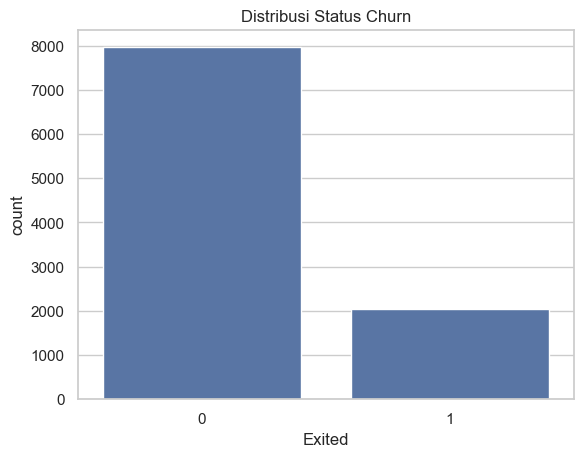

In [9]:
sns.countplot(x='Exited', data=df)
plt.title("Distribusi Status Churn")
plt.show()


In [10]:
df['Exited'].value_counts(normalize=True) * 100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

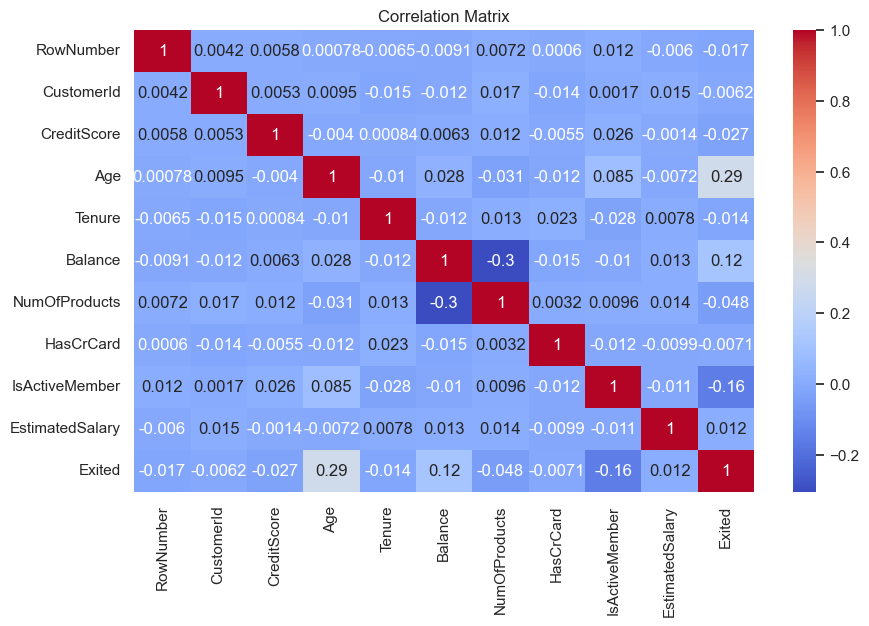

In [11]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


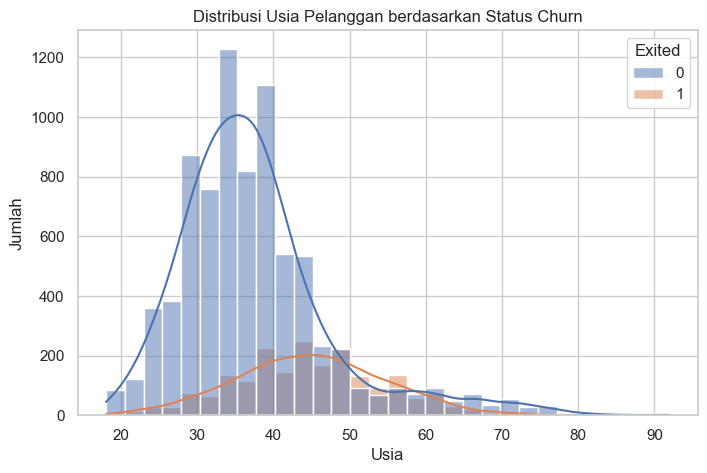

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Age", hue="Exited", bins=30, kde=True)
plt.title("Distribusi Usia Pelanggan berdasarkan Status Churn")
plt.xlabel("Usia")
plt.ylabel("Jumlah")
plt.show()

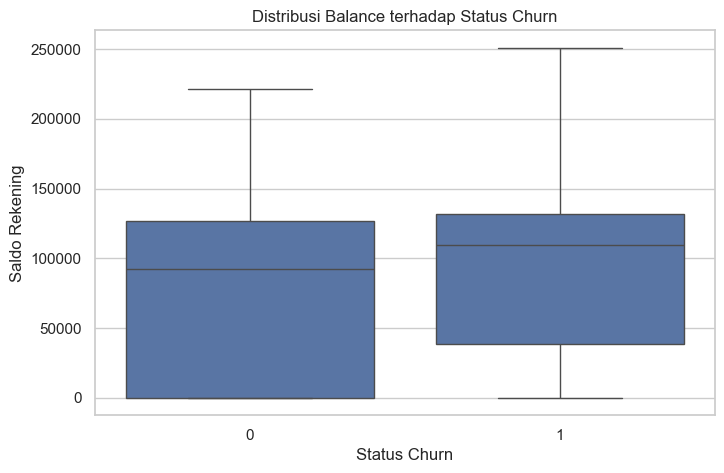

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Exited", y="Balance", data=df)
plt.title("Distribusi Balance terhadap Status Churn")
plt.xlabel("Status Churn")
plt.ylabel("Saldo Rekening")
plt.show()


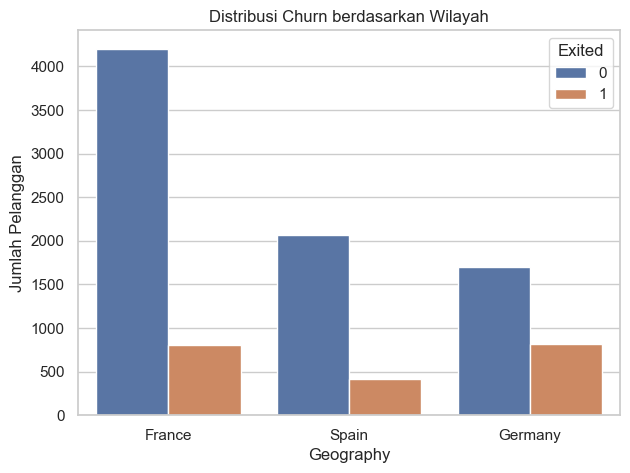

In [14]:
plt.figure(figsize=(7,5))
sns.countplot(x="Geography", hue="Exited", data=df)
plt.title("Distribusi Churn berdasarkan Wilayah")
plt.xlabel("Geography")
plt.ylabel("Jumlah Pelanggan")
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [19]:
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"], errors="ignore")

In [20]:
df = pd.get_dummies(df, columns=["Geography","Gender"], drop_first=True)

X = df.drop("Exited", axis=1)
y = df["Exited"]

print(X.shape)
print(y.shape)

(10000, 11)
(10000,)


## Memisahkan Fitur dan Target

Pada tahap ini dataset dipisahkan menjadi dua bagian yaitu:

- **Fitur (X)** yang digunakan sebagai input model
- **Target (y)** yang merupakan variabel yang ingin diprediksi yaitu status churn pelanggan.

In [16]:
X = df.drop("Exited", axis=1)
y = df["Exited"]

print(X.shape)
print(y.shape)

(10000, 11)
(10000,)


## Pembagian Data Latih dan Data Uji

Dataset dibagi menjadi dua bagian yaitu data latih (training data) dan data uji (testing data). 

Pembagian ini dilakukan dengan rasio **80:20**, di mana 80% data digunakan untuk melatih model dan 20% data digunakan untuk menguji performa model.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape) 

Train shape: (8000, 11)
Test shape: (2000, 11)


## Menyimpan Dataset Hasil Preprocessing

Setelah proses preprocessing selesai, data latih dan data uji disimpan ke dalam file CSV. Dataset ini akan digunakan pada tahap berikutnya yaitu pembangunan model machine learning.

In [18]:
train_data = pd.concat([X_train, y_train], axis=1)
test_data = pd.concat([X_test, y_test], axis=1)

train_data.to_csv("dataset_preprocessing/train_preprocessed.csv", index=False)
test_data.to_csv("dataset_preprocessing/test_preprocessed.csv", index=False)

print("Dataset preprocessing berhasil disimpan.")

Dataset preprocessing berhasil disimpan.
